# synthetic_control Exploration
## Introduction

One really interesting estimator I never went through at university in any real depth was **Synthetic Control**. This is a great shame because it is a really exciting and honestly quite old estimator now *(and when I was studying!)*. So I thought it might be nice to add a brief *(yet quite in depth)* exploration of this estimator. 

The most commonly used package is the `Synth` package in `R` by Jens Hainmueller and co: *Jens Hainmueller aut cre, Alexis Diamond aut, Alberto Abadie aut (2011). “Synth: An R Package for Synthetic Control Methods in Comparative Case Studies.” _Journal of Statistical Software_, 42(13), 1-17. <https://www.jstatsoft.org/v42/i13/>*.

Unlike `R` were `Synth` is the canonical package, python has a couple of different alternatives. One that is relatively similar to the `Synth` package is the `pysyncon`. It uses a similar syntax to the `Synth` package utilising a data prep object to organise the problems set up. 

@software{pysyncon,
  author = {Fordham, Stiofán},
  month = dec,
  title = {{pysyncon: a Python package for the Synthetic Control Method}},
  url = {https://github.com/sdfordham/pysyncon},
  year = {2022}
}

https://github.com/OscarEngelbrektson/SyntheticControlMethods/tree/master?tab=readme-ov-file

As with me [earlier exploration](https://github.com/Michael-Morgan-Giles/Panel_Data_Analysis/blob/main/9_synthetic_control/synthetic_control_exploration.Rmd) of Synthetic Control (SC) in `R`, I will look at a simple application using the `pysyncon` then dig a little bit deeper under the hood to see what the optimisation problem is doing.

So let's get into it by first loading the necessary packages for this notebook!


In [52]:
%reset -f

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cvxpy as cp
from scipy.optimize import minimize

pd.options.display.float_format = '{:20,.2f}'.format

# Synthetic Control Summary

The basic idea behind the SC is to construct a counterfactual i.e. what would have happened in the absence of of treatment. That is:

$$ Causal \quad Effect = Actual - Counterfactual$$

This is the fundamental problem of causal inference, because by definition we cannot observe the counterfactual. The SC tries to estimate this counterfactual position as the weight average of a control group i.e. a set of similar units that did not experience the same treatment as the treated unit. Slightly more formally, this means the above equation becomes:

$$ \tau_{1t} = Y_{1t} - WY_{0t} $$

Where both the $Y_{it}$ are the outcome variable of interest for the treated $(1)$ and control $(0)$ units and the $W$ is a vector of weights for each control unit. You can kind of think of each element of $W$ representing what percentage of the control units outcome variable should contribute to the counterfactual amount. 

This is a really nice approach because of its simplicity and easy interpretability. This approach can be quite easily explained to someone with very little economic background. Where the complexity arises comes is in how to choose the weights in $W$ *(and boy can it become complex)*. Specifically, this involves choosing $W$ that minimises the below optimisation problem:

$$
W^* = \operatorname{argmin_w} \quad (X_1 - WX_0)'V(X_1 - WX_0))
$$

$$
s.t \quad W \geq 0, \quad \iota'W = 1
$$

Now, before we get into the complexities of solving this problem let's explore an example to get a better idea of an application of SC.

# Synthetic Control Example

As with my earlier exploation, we can test the estimator using the example from the paper: *Andersson, J.J., 2019. Carbon taxes and CO2 emissions: Sweden as a case study. American Economic Journal: Economic Policy, 11(4), pp.1-30*.

The paper exploits a natural experiment to estimate the effect a carbon tax has on Co2 emissions. In 1990, Sweden was the first country in the world to implement a carbon tax. Because they were the first to implement a carbon tax, Sweden's emissions can be compared against other "similar" countries emissions to estimate the effect the carbon tax had on emissions. If you have some econometrics background, you might be thinking of applying a difference-in-differences estimator in a scenario like this and you wouldn't be the first to think that. Unfortunately, the dreaded parallel trends assumption for DiD has raised it's head again. Investigating the trends visually shows that a DiD estimator is potentially biased *(even if just slightly)*. 

In [61]:
from pysyncon import Dataprep, Synth

#Import data
co2 = pd.read_stata("/home/michael/Projects/essays/swedish_cp_replication/carbontax_fullsample_data.dta")

data = co2[(co2['country'].isin(["Sweden",
                  "Australia",
                  "Belgium",
                  "Canada",
                  "Denmark",
                  "France",
                  "Greece",
                  "Iceland",
                  "Japan",
                  "New Zealand",
                  "Poland",
                  "Portugal",
                  "Spain",
                  "Switzerland",
                  "United States"])) & 
                   (co2['year'] > 1959) &
                   (co2['year'] < 2006)]

controls = [c for c in data["country"].unique() if c != "Sweden"]
dp = Dataprep(
    foo=data,
    predictors=['GDP_per_capita', 
                'gas_cons_capita', 
                'vehicles_capita', 
                'urban_pop'], 
    predictors_op="mean",
    time_predictors_prior=range(1980, 1990),
    special_predictors=[
        ("CO2_transport_capita", [1989], "mean"),
        ("CO2_transport_capita", [1980], "mean"),
        ("CO2_transport_capita", [1970], "mean"),
    ],
    dependent="CO2_transport_capita",
    unit_variable="country",
    time_variable="year",
    treatment_identifier="Sweden",
    controls_identifier=controls,
    time_optimize_ssr=range(1960, 1990),
)
synth = Synth()
synth.fit(dataprep=dp, optim_method="Nelder-Mead")

del data

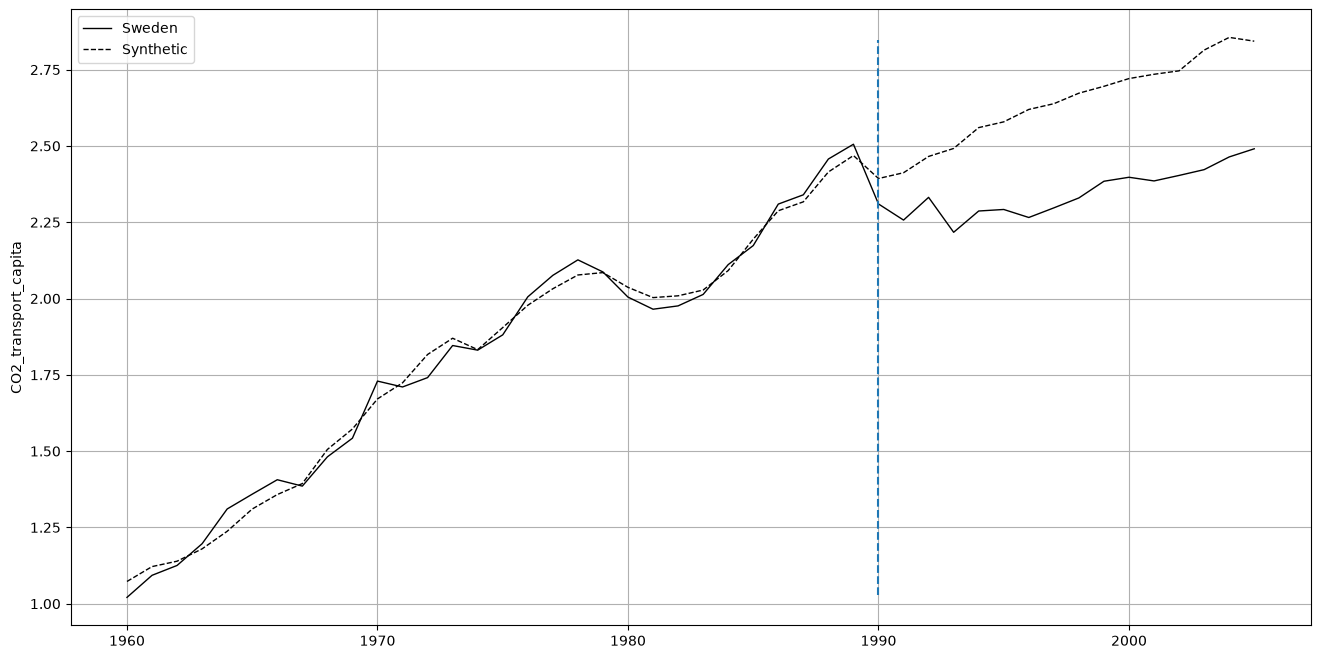

In [62]:
plt.figure(figsize = (16,8))
synth.path_plot(time_period=range(1960, 2006), treatment_time=1990)

# My random workings for now...

In [56]:
co2 = pd.read_stata("/home/michael/Projects/essays/swedish_cp_replication/carbontax_fullsample_data.dta")

co2 = co2[(co2['country'].isin(["Sweden",
                  "Australia",
                  "Belgium",
                  "Canada",
                  "Denmark",
                  "France",
                  "Greece",
                  "Iceland",
                  "Japan",
                  "New Zealand",
                  "Poland",
                  "Portugal",
                  "Spain",
                  "Switzerland",
                  "United States"])) & 
                   (co2['year'] > 1959) &
                   (co2['year'] < 2006)]


covariates = ['GDP_per_capita', 
              'gas_cons_capita', 
              'vehicles_capita', 
              'urban_pop']

outcome_var = 'CO2_transport_capita'
treatment_period = 1990
time_var = "year"
id_var = "Countryno"
treated_unit = 21

periods_all = co2[time_var].nunique()
periods_pre_treatment = co2.loc[co2[time_var]<treatment_period][time_var].nunique()
n_controls = co2[id_var].nunique() - 1
control_units = co2.loc[co2[id_var] != treated_unit][id_var].unique()

# treated transforms
treated_data_all = co2.loc[co2[id_var] == treated_unit]
treated_outcome_all = np.array(treated_data_all[outcome_var]).reshape(periods_all,1) #All outcomes

##Only pre-treatment
treated_data = treated_data_all.loc[co2[time_var] < treatment_period]
#Extract outcome and shape as matrix
treated_outcome = np.array(treated_data[outcome_var]).reshape(periods_pre_treatment, 1)

X_1 = co2[(co2['year'] >= 1980) & (co2['year'] < 1990) & 
         (co2['country'] == "Sweden")].groupby(['Countryno'])[covariates].mean()


X_1 = pd.merge(X_1,
         co2[co2['year'] == 1989].groupby("Countryno")['CO2_transport_capita'].mean().reset_index(),
        how = "left",
        on = 'Countryno').rename(columns = {"CO2_transport_capita" : "CO2_transport_capita_1989"})

X_1 = pd.merge(X_1,
         co2[co2['year'] == 1980].groupby("Countryno")['CO2_transport_capita'].mean().reset_index(),
        how = "left",
        on = 'Countryno').rename(columns = {"CO2_transport_capita" : "CO2_transport_capita_1980"})

X_1 = pd.merge(X_1,
         co2[co2['year'] == 1970].groupby("Countryno")['CO2_transport_capita'].mean().reset_index(),
        how = "left",
        on = 'Countryno').rename(columns = {"CO2_transport_capita" : "CO2_transport_capita_1970"}).drop(columns = ['Countryno']).T


#Every unit that is not the treated unit is control
control_data_all = co2.loc[co2[id_var] != treated_unit]
control_outcome_all = np.array(control_data_all[outcome_var]).reshape(n_controls, periods_all).T 
        
#Only pre-treatment
control_data = control_data_all.loc[co2[time_var] < treatment_period]
#Extract outcome, then shape as matrix
control_outcome = np.array(control_data[outcome_var]).reshape(n_controls, periods_pre_treatment).T
        
X_0 = co2[(co2['year'] >= 1980) & (co2['year'] < 1990) & 
         (co2['country'] != "Sweden")].groupby(['Countryno'])[covariates].mean()


X_0 = pd.merge(X_0,
         co2[co2['year'] == 1989].groupby("Countryno")['CO2_transport_capita'].mean().reset_index(),
        how = "left",
        on = 'Countryno').rename(columns = {"CO2_transport_capita" : "CO2_transport_capita_1989"})

X_0 = pd.merge(X_0,
         co2[co2['year'] == 1980].groupby("Countryno")['CO2_transport_capita'].mean().reset_index(),
        how = "left",
        on = 'Countryno').rename(columns = {"CO2_transport_capita" : "CO2_transport_capita_1980"})

X_0 = pd.merge(X_0,
         co2[co2['year'] == 1970].groupby("Countryno")['CO2_transport_capita'].mean().reset_index(),
        how = "left",
        on = 'Countryno').rename(columns = {"CO2_transport_capita" : "CO2_transport_capita_1970"}).drop(columns = ['Countryno']).T

# load in other data
treated_covariates = np.asarray(X_1)
control_covariates = np.asarray(X_0)

n_covariates = len(control_covariates)

## scaled covariariates by varaince
df = np.column_stack((X_0, X_1))

divisor = np.sqrt(df.var(axis=1, ddof=1))

scaled_matrix = df * (1.0 / divisor)[:, np.newaxis]

del df

control_covariates = scaled_matrix[:, :n_controls]
treated_covariates = scaled_matrix[:, -1]

# resahpe treated covs - if you don't reshape the array it wigs out the optimsation problem (this took me ages to figure out)
treated_covariates = treated_covariates.reshape(-1, 1)

# optimisation problem
args = (treated_outcome, treated_covariates, # Z_1, X_1
        control_outcome, control_covariates) # Z_0, X_0

# assume initial starting v of uniform weights
v_0 = np.full(n_covariates, 1/n_covariates)

# set bounds based on covariates
bnds = tuple((0,1) for _ in range(n_covariates))

#total_looss func
def w_v_loss_func(v_0, 
               treated_outcome, 
               treated_covariates,
               control_outcome, 
               control_covariates):
    
    n_controls = control_outcome.shape[1]
    
    v_0 = np.abs(v_0) / np.sum(np.abs(v_0))
    V = np.diag(v_0)

    w = cp.Variable((n_controls, 1), nonneg=True)
    
    treated_synth_difference = cp.sum(V @ cp.square(treated_covariates - control_covariates @ w))
    
    objective = cp.Minimize(treated_synth_difference)
    
    constraints = [cp.sum(w) == 1, w >= 0, w <= 1]
    
    problem = cp.Problem(objective, constraints)
    
    result = problem.solve(verbose=False)
    loss = (treated_outcome - control_outcome @ w.value).T @ (treated_outcome - control_outcome @ w.value)
    loss = loss / len(control_outcome)

    return loss

# optimise the nested function
res = minimize(w_v_loss_func, 
               v_0,  
               args=(args),
               method='Nelder-Mead',
               #method='BFGS',
               bounds=bnds)

V_Star = abs(res.x) /  sum(abs(res.x))

np.round(V_Star,4)

array([0.0947, 0.0188, 0.0714, 0.2495, 0.1104, 0.3879, 0.0673])

In [57]:
n_controls = control_outcome.shape[1]

# Construct the problem - constrain weights to be non-negative
w = cp.Variable((n_controls, 1), nonneg=True)
    
treated_synth_difference = cp.sum(V_Star @ cp.square(treated_covariates - control_covariates @ w))
    
objective = cp.Minimize(treated_synth_difference)
    
constraints = [cp.sum(w) == 1] # non negative weights assigned above in w
    
problem = cp.Problem(objective, constraints)
    
result = problem.solve(verbose=False)
loss = (treated_outcome - control_outcome @ w.value).T @ (treated_outcome - control_outcome @ w.value)
    
np.round(w.value,4)

array([[0.    ],
       [0.1965],
       [0.    ],
       [0.3802],
       [0.    ],
       [0.0903],
       [0.    ],
       [0.    ],
       [0.1812],
       [0.    ],
       [0.    ],
       [0.    ],
       [0.0642],
       [0.0876]])

Potential explanation for the slightly different $V^*$ but approximately identical $W^*$ [here](https://mpra.ub.uni-muenchen.de/106390/14/MPRA_paper_106390.pdf).

<Axes: xlabel='year', ylabel='value'>

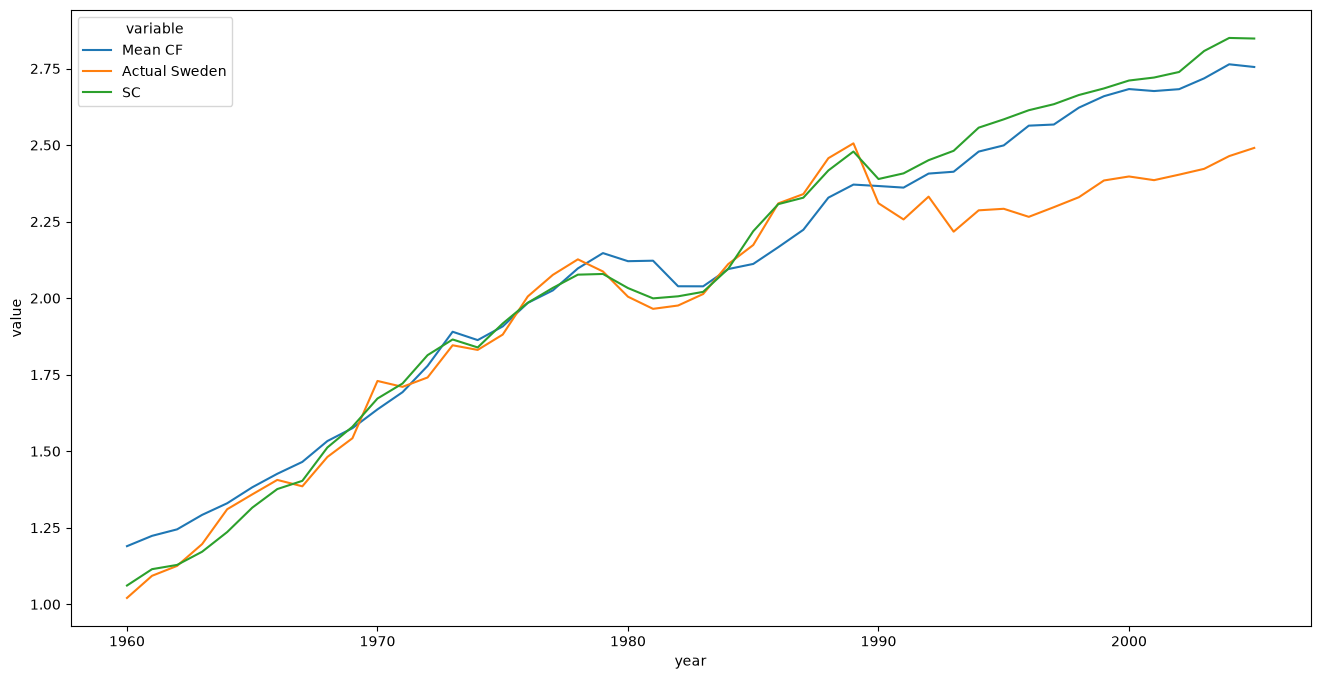

In [58]:
plot_df = pd.melt(pd.merge(pd.merge(co2[(co2['year'] >= 1960) &
          (co2['country'] != "Sweden")].pivot(index = "Countryno", 
                                              columns = 'year', 
                                              values = "CO2_transport_capita").mean().reset_index().rename(columns = {0 : "Mean CF"}),
         co2[(co2['year'] >= 1960) &
             (co2['country'] == "Sweden")].pivot(index = "Countryno", 
                                             columns = 'year', 
                                             values = "CO2_transport_capita").mean().reset_index().rename(columns = {0 : "Actual Sweden"}),
        how = "left",
        on = "year"),
         co2[(co2['year'] >= 1960) &
         (co2['country'] != "Sweden")].pivot(index = "year", 
                                             columns = 'Countryno', 
                                             values = "CO2_transport_capita").dot(w.value).reset_index().rename(columns = {0 : "SC"}),

        how = "left",
        on = "year"),
       id_vars=["year"])

plt.figure(figsize = (16,8))
sns.lineplot(data = plot_df, x = "year", y = "value", hue = "variable")